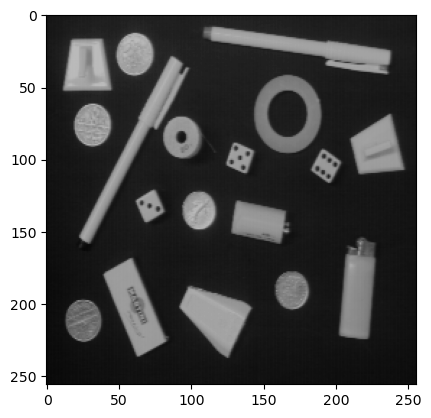

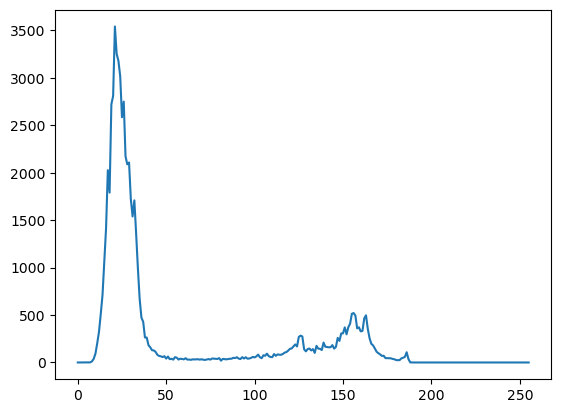

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

objects = cv2.imread('objects.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(objects, cmap='gray', vmin=0, vmax=255)
plt.show()

objects_hist = cv2.calcHist([objects], [0], None, [256], [0, 256])
plt.plot(objects_hist)
plt.show()


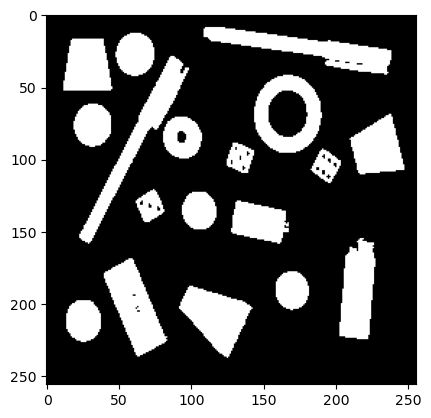

In [2]:
thres_value, thres_objects = cv2.threshold(objects, 70, 255, cv2.THRESH_BINARY)
plt.imshow(thres_objects, cmap='gray')
plt.show()


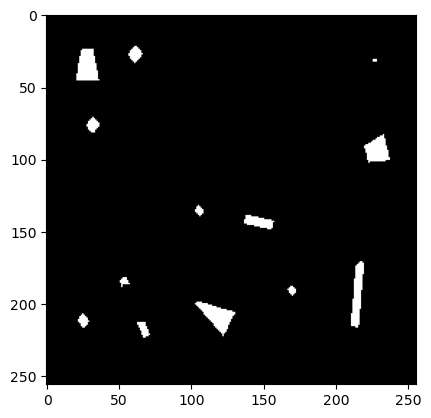

In [3]:
from skimage.morphology import dilation, erosion, opening, closing
area = np.ones((15, 15))
eroded_thres_objects = erosion(thres_objects, footprint=area)

plt.imshow(eroded_thres_objects, cmap='gray')
plt.show()

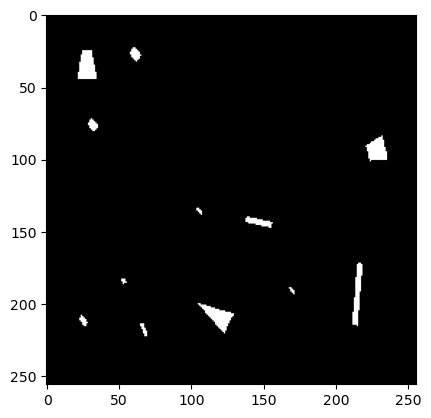

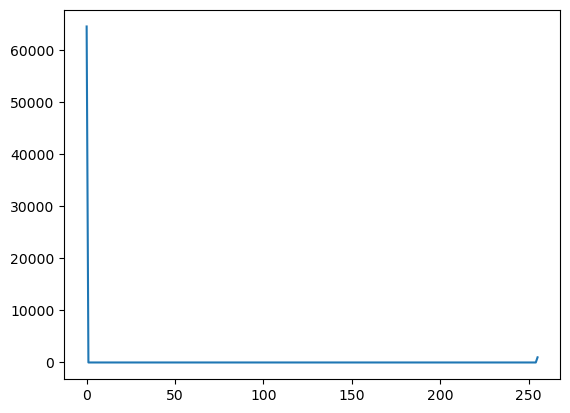

In [4]:

mascara_oblicua_descendente = np.array([[1, None, None], [None, 1, None], [None, None, 1]], dtype=object)
mascara_oblicua_ascendente = np.array([[None, None, 1], [None, 1, None], [1, None, None]], dtype=object)



eroded_image = erosion(eroded_thres_objects, footprint=mascara_oblicua_ascendente)



plt.imshow(eroded_image, cmap='gray')
plt.show()

eroded_hist = cv2.calcHist([eroded_image], [0], None, [256], [0, 256])
plt.plot(eroded_hist)
plt.show()

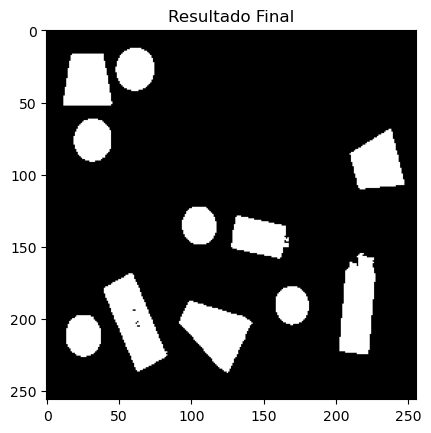

In [5]:
coordinates = np.column_stack(np.where(eroded_image == 255))

def dist_mayor(x, y):
    return np.sqrt((x[0] - y[0])**2 + (x[1] - y[1])**2) > 30

for i in range(len(coordinates)):
    for j in range(i+1, len(coordinates)):
        if not dist_mayor(coordinates[i], coordinates[j]):
            coordinates[j] = 0

from skimage.segmentation import flood


tolerancia= 0.2
mascara = np.zeros_like(thres_objects)
for i in coordinates:
    if i[0] != 0:
        semilla = (i[0], i[1])  

        mascara= mascara + flood(thres_objects, semilla, tolerance=tolerancia)

mascara[mascara > 0] = 255
plt.imshow(mascara, cmap='gray')
plt.title("Resultado Final")
plt.show()


